# PRAKTIKUM PENAMBANGAN DATA (PPD)
## MODUL 6: CLUSTERING

* **Nama**: Januarsyah Akbar
* **NIM**: 24/535846/SV/24314
* **Kelas**: B2
* **Mata Kuliah**: Praktikum Penambangan Data (SVPL214610)
* **Program Studi**: D4 Teknologi Rekayasa Perangkat Lunak, Sekolah Vokasi UGM

---

## A. LANGKAH PERCOBAAN: CREDIT CARD CLUSTERING
Dataset: [Credit Card Dataset for Clustering](https://raw.githubusercontent.com/ganjar87/data_science_practice/main/CC%20GENERAL.csv)

### 1. Inisialisasi & Setup Lingkungan Colab / Local
Mempersiapkan dependensi pustaka dan skrip unduh dataset otomatis agar notebook Colab-Ready.

In [1]:
import os
import urllib.request
import ssl

# Handler SSL & Download Dataset
ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE

os.makedirs('data', exist_ok=True)

# Dataset 1: CreditCard
url_cc = 'https://raw.githubusercontent.com/ganjar87/data_science_practice/main/CC%20GENERAL.csv'
path_cc = 'data/CreditCard.csv'
if not os.path.exists(path_cc):
    try:
        req = urllib.request.Request(url_cc, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req, context=ctx) as response:
            with open(path_cc, 'wb') as f:
                f.write(response.read())
        print("Dataset Credit Card berhasil diunduh!")
    except Exception as e:
        print("Gagal mengunduh Credit Card:", e)
else:
    print("Dataset Credit Card sudah tersedia lokal.")

# Dataset 2: Air Traffic
url_air = 'https://data.sfgov.org/resource/rkru-6vcg.csv?$limit=50000'
path_air = 'data/Air_Traffic_Passenger_Statistics.csv'
if not os.path.exists(path_air):
    try:
        req = urllib.request.Request(url_air, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req, context=ctx) as response:
            with open(path_air, 'wb') as f:
                f.write(response.read())
        print("Dataset Air Traffic berhasil diunduh!")
    except Exception as e:
        print("Gagal mengunduh Air Traffic:", e)
else:
    print("Dataset Air Traffic sudah tersedia lokal.")

Dataset Credit Card sudah tersedia lokal.
Dataset Air Traffic sudah tersedia lokal.


### 2. Impor Pustaka (Library)
Mengimpor library manipulasi data, analisis statistik, standarisasi, algoritma clustering (K-Means, K-Medoids), evaluasi, serta visualisasi.

In [2]:
# Instalasi dependensi tambahan untuk lingkungan Google Colab
!pip install -q scikit-learn-extra kneed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_samples, silhouette_score
from kneed import KneeLocator
import plotly.express as px

print("Seluruh pustaka berhasil diimpor!")

Seluruh pustaka berhasil diimpor!


### 3. Membaca dan Memeriksa Informasi Dataset
Memuat dataset Credit Card ke dalam DataFrame pandas dan menampilkan sampel data awal, ukuran matriks, ringkasan statistik, serta korelasi antar-fitur.

In [3]:
# Load dataset Credit Card
try:
    df = pd.read_csv('https://raw.githubusercontent.com/ganjar87/data_science_practice/main/CC%20GENERAL.csv')
except Exception:
    df = pd.read_csv('data/CreditCard.csv')

df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
# Ukuran/Dimensi dataset
print("Dimensi dataset:", df.shape)

Dimensi dataset: (8950, 18)


In [5]:
# Ringkasan statistik deskriptif
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


In [6]:
# Matriks korelasi antar kolom numerik
df.corr(numeric_only=True)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
BALANCE,1.000000,0.322412,0.181261,0.164350,0.126469,0.496692,-0.077944,0.073166,-0.063186,0.449218,0.385152,0.154338,0.531283,0.322802,0.398684,-0.318959,0.072692
BALANCE_FREQUENCY,0.322412,1.000000,0.133674,0.104323,0.124292,0.099388,0.229715,0.202415,0.176079,0.191873,0.141555,0.189626,0.095843,0.065008,0.132569,-0.095082,0.119776
PURCHASES,0.181261,0.133674,1.000000,0.916845,0.679896,-0.051474,0.393017,0.498430,0.315567,-0.120143,-0.067175,0.689561,0.356963,0.603264,0.093860,0.180379,0.086288
ONEOFF_PURCHASES,0.164350,0.104323,0.916845,1.000000,0.330622,-0.031326,0.264937,0.524891,0.127729,-0.082628,-0.046212,0.545523,0.319724,0.567292,0.048755,0.132763,0.064150
INSTALLMENTS_PURCHASES,0.126469,0.124292,0.679896,0.330622,1.000000,-0.064244,0.442418,0.214042,0.511351,-0.132318,-0.073999,0.628108,0.256499,0.384084,0.132172,0.182569,0.086143
CASH_ADVANCE,0.496692,0.099388,-0.051474,-0.031326,-0.064244,1.000000,-0.215507,-0.086754,-0.177070,0.628522,0.656498,-0.075850,0.303985,0.453238,0.140107,-0.152935,-0.068312
PURCHASES_FREQUENCY,-0.077944,0.229715,0.393017,0.264937,0.442418,-0.215507,1.000000,0.501343,0.862934,-0.308478,-0.203478,0.568430,0.119788,0.103464,0.003030,0.305802,0.061506
ONEOFF_PURCHASES_FREQUENCY,0.073166,0.202415,0.498430,0.524891,0.214042,-0.086754,0.501343,1.000000,0.142329,-0.111716,-0.069088,0.544869,0.295038,0.243537,-0.030327,0.157531,0.082466
PURCHASES_INSTALLMENTS_FREQUENCY,-0.063186,0.176079,0.315567,0.127729,0.511351,-0.177070,0.862934,0.142329,1.000000,-0.262958,-0.169207,0.529975,0.060755,0.085551,0.030073,0.250087,0.073275
CASH_ADVANCE_FREQUENCY,0.449218,0.191873,-0.120143,-0.082628,-0.132318,0.628522,-0.308478,-0.111716,-0.262958,1.000000,0.799561,-0.131168,0.132616,0.183192,0.098838,-0.249773,-0.133372


### 4. Data Cleaning (Pembersihan Data)
Menghapus atribut identitas (`CUST_ID`) dan melakukan imputasi nilai kosong (*missing values*) pada fitur `MINIMUM_PAYMENTS` serta `CREDIT_LIMIT` menggunakan nilai median.

In [7]:
# Menghapus kolom CUST_ID
df_new = df.drop('CUST_ID', axis=1)
df_new.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [8]:
# Cek jumlah missing values sebelum imputasi
df_new.isnull().sum()

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [9]:
# Imputasi missing values dengan median
df_new['MINIMUM_PAYMENTS'] = df_new['MINIMUM_PAYMENTS'].fillna(df_new['MINIMUM_PAYMENTS'].median())
df_new['CREDIT_LIMIT'] = df_new['CREDIT_LIMIT'].fillna(df_new['CREDIT_LIMIT'].median())

# Cek hasil imputasi
df_new.isnull().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

### 5. Standarisasi Data (Feature Scaling)
Mengubah skala data menggunakan `StandardScaler` agar seluruh fitur memiliki rata-rata ($\mu = 0$) dan standar deviasi ($\sigma = 1$).

In [10]:
# Scaling
X = df_new.astype(float).values
scaler = StandardScaler().fit(X)
X_new = scaler.transform(X)
print("Bentuk matriks X_new:", X_new.shape)
X_new

Bentuk matriks X_new: (8950, 17)


array([[-0.73198937, -0.24943448, -0.42489974, ..., -0.3024    ,
        -0.52555097,  0.36067954],
       [ 0.78696085,  0.13432467, -0.46955188, ...,  0.09749953,
         0.2342269 ,  0.36067954],
       [ 0.44713513,  0.51808382, -0.10766823, ..., -0.0932934 ,
        -0.52555097,  0.36067954],
       ...,
       [-0.7403981 , -0.18547673, -0.40196519, ..., -0.32687479,
         0.32919999, -4.12276757],
       [-0.74517423, -0.18547673, -0.46955188, ..., -0.33830497,
         0.32919999, -4.12276757],
       [-0.57257511, -0.88903307,  0.04214581, ..., -0.3243581 ,
        -0.52555097, -4.12276757]])

### 6. Menentukan Jumlah Cluster Optimal (Elbow Method & Silhouette Score)
Melakukan pengujian jumlah kluster $k=1 \dots 10$ menggunakan metrik Inertia (WCSS) dan Silhouette Score untuk algoritma K-Means dan K-Medoids.

#### a. Elbow Method untuk K-Means

In [11]:
# Metode Elbow K-Means
inertia_list_km = []
for num_clusters in range(1, 11):
    kmeans_model = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    kmeans_model.fit(X_new)
    inertia_list_km.append(kmeans_model.inertia_)
    print("For n_clusters = {}, inertia value is {}".format(num_clusters, kmeans_model.inertia_))

For n_clusters = 1, inertia value is 152150.0


For n_clusters = 2, inertia value is 127784.53454477157


For n_clusters = 3, inertia value is 111975.04359325659


For n_clusters = 4, inertia value is 99061.93984229014


For n_clusters = 5, inertia value is 91490.49803950504


For n_clusters = 6, inertia value is 84826.59203083461


For n_clusters = 7, inertia value is 79856.15701773313


For n_clusters = 8, inertia value is 74484.88006180587


For n_clusters = 9, inertia value is 69828.69926874826


For n_clusters = 10, inertia value is 66466.4149287434


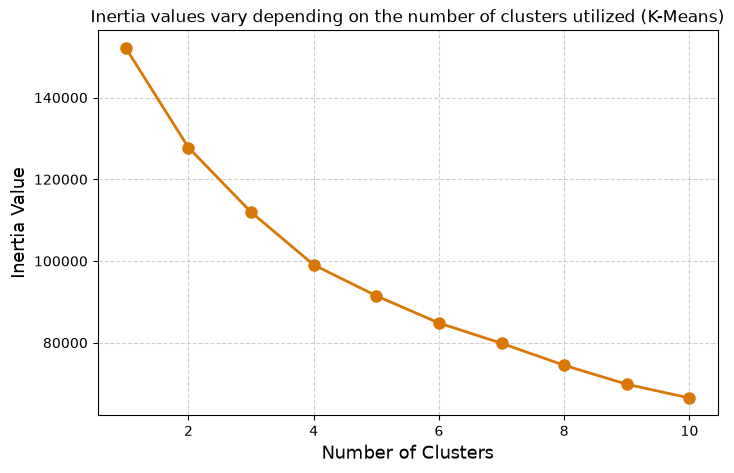

In [12]:
# Visualisasi Metode Elbow K-Means
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia_list_km, marker='o', linewidth=2, markersize=8, color='#d97706')
plt.xlabel("Number of Clusters", size=13)
plt.ylabel("Inertia Value", size=13)
plt.title("Inertia values vary depending on the number of clusters utilized (K-Means)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Knee optimal: 4
Elbow optimal: 4


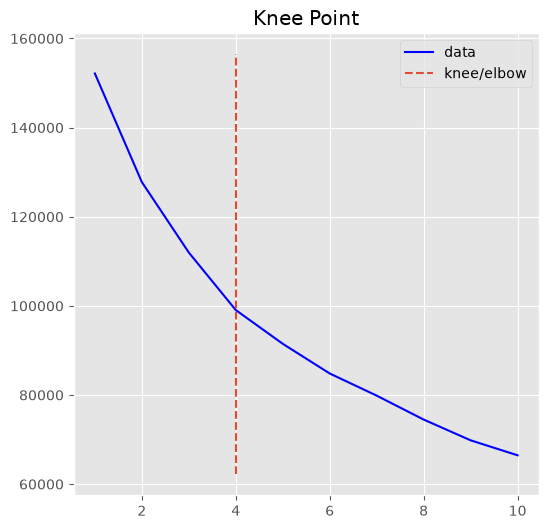

In [13]:
# Menentukan titik optimal K-Means menggunakan kneed
kneedle_km = KneeLocator(range(1, 11), inertia_list_km, S=1.0, curve='convex', direction='decreasing')
print("Knee optimal:", round(kneedle_km.knee, 3))
print("Elbow optimal:", round(kneedle_km.elbow, 3))

# Visualisasi knee point
plt.style.use('ggplot')
kneedle_km.plot_knee()
plt.show()

#### b. Elbow Method untuk K-Medoids

In [14]:
# Metode Elbow K-Medoids
inertia_list_kmed = []
for num_clusters in range(1, 11):
    kmedoids_model = KMedoids(n_clusters=num_clusters, random_state=42)
    kmedoids_model.fit(X_new)
    inertia_list_kmed.append(kmedoids_model.inertia_)
    print(f"The inertia of {num_clusters} clusters : {kmedoids_model.inertia_}")

The inertia of 1 clusters : 32074.48996380632


The inertia of 2 clusters : 28502.25208385186


The inertia of 3 clusters : 26690.45199631644


The inertia of 4 clusters : 25312.680447648516


The inertia of 5 clusters : 24410.149064611873


The inertia of 6 clusters : 25045.95980572694


The inertia of 7 clusters : 23865.264137616654


The inertia of 8 clusters : 23728.760888976765


The inertia of 9 clusters : 21901.10586964694


The inertia of 10 clusters : 23064.595738133597


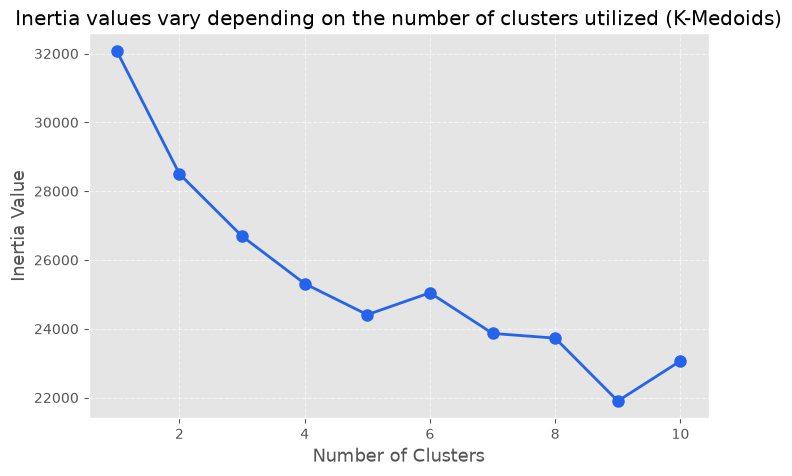

In [15]:
# Visualisasi Metode Elbow K-Medoids
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia_list_kmed, marker='o', linewidth=2, markersize=8, color='#2563eb')
plt.xlabel("Number of Clusters", size=13)
plt.ylabel("Inertia Value", size=13)
plt.title("Inertia values vary depending on the number of clusters utilized (K-Medoids)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

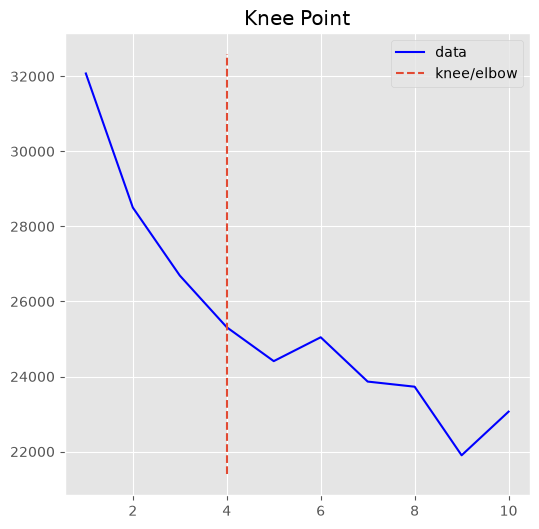

In [16]:
# Menentukan titik optimal K-Medoids dengan kneed
kneedle_kmed = KneeLocator(range(1, 11), inertia_list_kmed, S=1.0, curve='convex', direction='decreasing')
plt.style.use('ggplot')
kneedle_kmed.plot_knee()
plt.show()

#### c. Silhouette Score untuk K-Means

In [17]:
# Menentukan Silhouette Score K-Means
sh_list_km = []
for num_clusters in range(2, 11):
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_new)
    score = silhouette_score(X_new, cluster_labels)
    sh_list_km.append(score)
    print("For n_clusters = {}, silhouette score is {}".format(num_clusters, score))

For n_clusters = 2, silhouette score is 0.21004304743383298


For n_clusters = 3, silhouette score is 0.25098792290537314


For n_clusters = 4, silhouette score is 0.1976791965228765


For n_clusters = 5, silhouette score is 0.19311230479899416


For n_clusters = 6, silhouette score is 0.20286011584987834


For n_clusters = 7, silhouette score is 0.2076861400058817


For n_clusters = 8, silhouette score is 0.2216984741387776


For n_clusters = 9, silhouette score is 0.22603401853576208


For n_clusters = 10, silhouette score is 0.22043791081245337


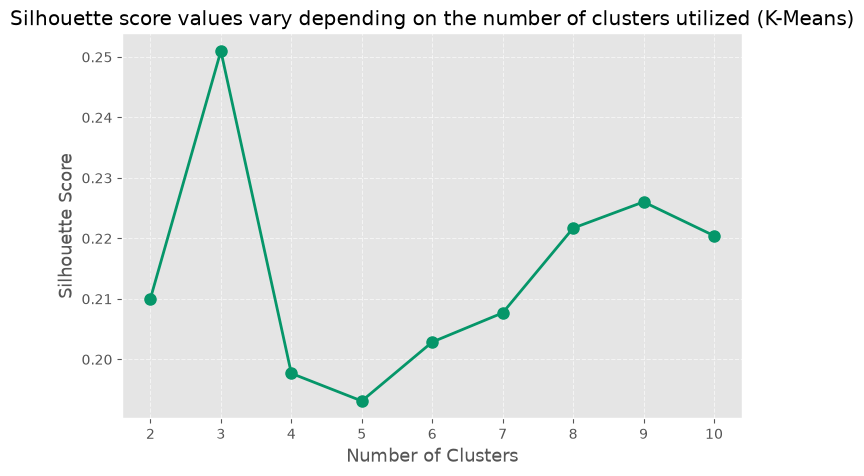

In [18]:
# Visualisasi Silhouette Score K-Means
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), sh_list_km, marker='o', linewidth=2, markersize=8, color='#059669')
plt.xlabel("Number of Clusters", size=13)
plt.ylabel("Silhouette Score", size=13)
plt.title("Silhouette score values vary depending on the number of clusters utilized (K-Means)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### d. Silhouette Score untuk K-Medoids

In [19]:
# Menentukan Silhouette Score K-Medoids
sh_list_kmed = []
for num_clusters in range(2, 11):
    kmedoids = KMedoids(n_clusters=num_clusters, random_state=42)
    cluster_labels = kmedoids.fit_predict(X_new)
    score = silhouette_score(X_new, cluster_labels)
    sh_list_kmed.append(score)
    print("For n_clusters = {}, silhouette score is {}".format(num_clusters, score))

For n_clusters = 2, silhouette score is 0.1945165537378692


For n_clusters = 3, silhouette score is 0.16024040458444103


For n_clusters = 4, silhouette score is 0.13738603460433332


For n_clusters = 5, silhouette score is 0.14859330798827058


For n_clusters = 6, silhouette score is 0.07497117420304265


For n_clusters = 7, silhouette score is 0.05119359110042946


For n_clusters = 8, silhouette score is 0.03912406632314491


For n_clusters = 9, silhouette score is 0.08491760468793151


For n_clusters = 10, silhouette score is 0.03469231089500276


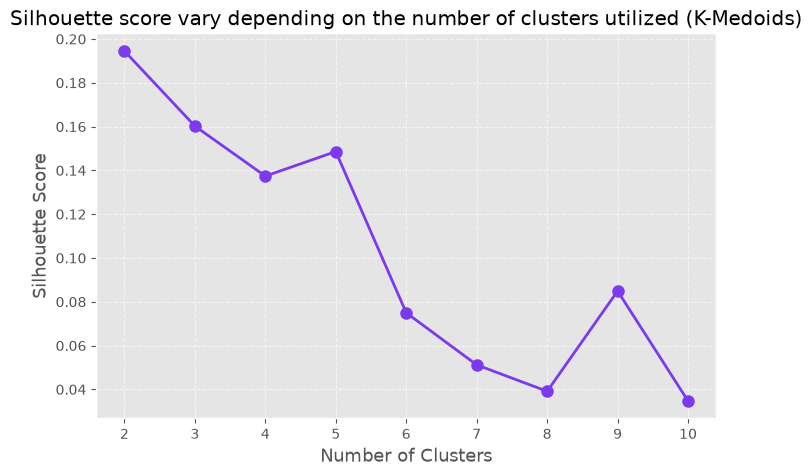

In [20]:
# Visualisasi Silhouette Score K-Medoids
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), sh_list_kmed, marker='o', linewidth=2, markersize=8, color='#7c3aed')
plt.xlabel("Number of Clusters", size=13)
plt.ylabel("Silhouette Score", size=13)
plt.title("Silhouette score vary depending on the number of clusters utilized (K-Medoids)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 7. Menerapkan Algoritma K-Means
Melatih model K-Means menggunakan $k=2$ (berdasarkan Silhouette Score optimal) dan memvisualisasikan persebaran titik kluster dalam grafik 2D dan 3D.

In [21]:
# Pelatihan K-Means dengan k=2
k_means = KMeans(n_clusters=2, random_state=42, n_init=10)
k_means.fit(X_new)
labels_km = k_means.labels_
df_new['cluster_labels'] = labels_km
df_new.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster_labels
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,1
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,1
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12,1
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,1


In [22]:
# Cek Centroids K-Means
centroids_km = k_means.cluster_centers_
print("Dimensi Centroids:", centroids_km.shape)
centroids_km

Dimensi Centroids: (2, 17)


array([[-0.08744422,  0.29020589,  0.48135137,  0.33312274,  0.52586121,
        -0.25537879,  1.03682468,  0.53673444,  0.9260555 , -0.38135421,
        -0.26756991,  0.64627632,  0.16934511,  0.15928462,  0.00899867,
         0.40053725,  0.12182888],
       [ 0.06165575, -0.20462031, -0.33939444, -0.23488041, -0.37077774,
         0.18006418, -0.73105128, -0.37844431, -0.6529494 ,  0.26888777,
         0.18865998, -0.45568083, -0.11940298, -0.11230947, -0.00634484,
        -0.28241348, -0.08589992]])

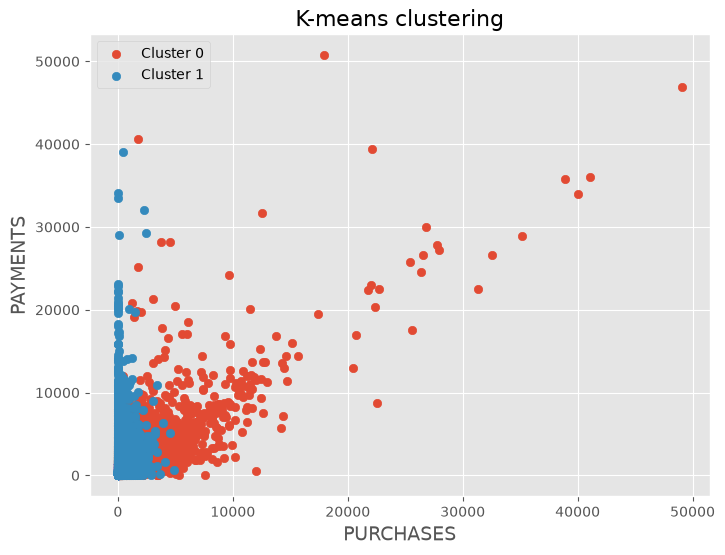

In [23]:
# Visualisasi Scatter Plot 2D Matplotlib
x1 = df_new['PURCHASES']
x2 = df_new['PAYMENTS']

plt.figure(figsize=(8, 6))
u_labels = np.unique(labels_km)
for i in u_labels:
    plt.scatter(x1[df_new['cluster_labels'] == i], x2[df_new['cluster_labels'] == i], label=f'Cluster {i}')

plt.xlabel(x1.name, fontsize=14)
plt.ylabel(x2.name, fontsize=14)
plt.title('K-means clustering', fontsize=16)
plt.legend()
plt.show()

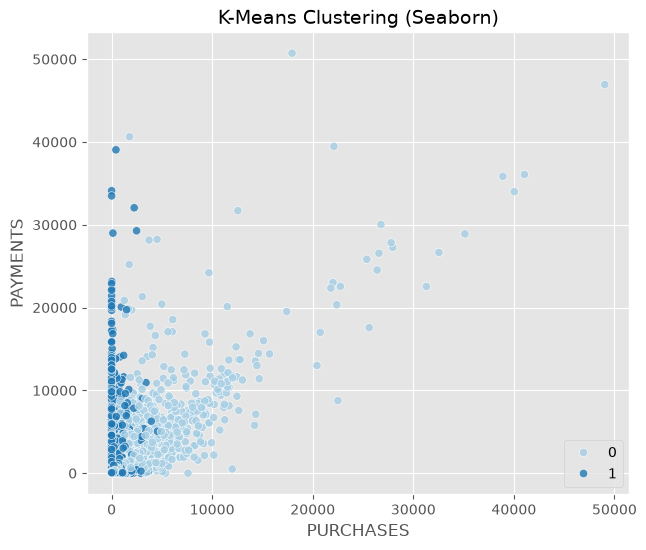

In [24]:
# Visualisasi Scatter Plot 2D Seaborn
plt.figure(figsize=(7, 6))
sns.scatterplot(x='PURCHASES', y='PAYMENTS', hue='cluster_labels', data=df_new, palette='Paired', alpha=0.8)
plt.title('K-Means Clustering (Seaborn)', fontsize=14)
plt.legend(loc='lower right')
plt.show()

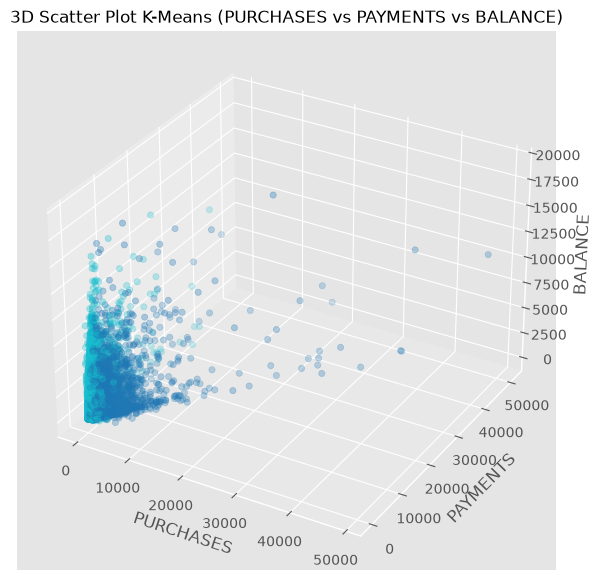

In [25]:
# Visualisasi Scatter 3D Plotly (Diproksikan ke Matplotlib 3D untuk Static Export)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(df_new['PURCHASES'], df_new['PAYMENTS'], df_new['BALANCE'], c=df_new['cluster_labels'], cmap='tab10', alpha=0.6)
ax.set_xlabel('PURCHASES')
ax.set_ylabel('PAYMENTS')
ax.set_zlabel('BALANCE')
plt.title('3D Scatter Plot K-Means (PURCHASES vs PAYMENTS vs BALANCE)', fontsize=12)
plt.show()

### 8. Menerapkan Algoritma K-Medoids
Melatih model K-Medoids menggunakan $k=4$ (berdasarkan hasil Elbow Method) dan memvisualisasikan persebaran 4 kelompok nasabah.

In [26]:
# Pelatihan K-Medoids dengan k=4
k_medoids = KMedoids(n_clusters=4, random_state=42)
k_medoids.fit(X_new)
labels_kmed = k_medoids.labels_
df_new['cluster_labels'] = labels_kmed
df_new.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster_labels
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,1
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,3
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,2
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12,0
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,1


In [27]:
# Cek Medoids/Centroids K-Medoids
centroids_kmed = k_medoids.cluster_centers_
print("Dimensi Medoids:", centroids_kmed.shape)
centroids_kmed

Dimensi Medoids: (4, 17)


array([[-0.73017008, -1.78447531, -0.15174467,  0.01660604, -0.3893315 ,
        -0.46678555, -0.39122513, -0.39931927, -0.49762862, -0.67534886,
        -0.47606982, -0.39063931, -0.20456068, -0.35069111, -0.32756103,
         0.50015018,  0.36067954],
       [-0.04321221,  0.51808382, -0.41993839, -0.29307072, -0.45457623,
        -0.44947139, -1.01412545, -0.39931927, -0.91699519, -0.25891333,
        -0.18299798, -0.51133325, -0.41069279, -0.47801089, -0.17593333,
        -0.52555097,  0.36067954],
       [-0.65121444,  0.51808382,  0.24224266,  0.03901242,  0.50039651,
        -0.46678555,  1.06221062,  0.15936716,  1.38951716, -0.67534886,
        -0.47606982,  0.37375564, -0.27327139,  0.0131038 , -0.2796588 ,
         0.04428414,  0.36067954],
       [ 1.16410803,  0.51808382, -0.40096824, -0.32982224, -0.3423    ,
         0.80421891, -0.18359002, -0.39931927, -0.2879466 ,  1.8232743 ,
         0.69621752, -0.350408  ,  0.41383563, -0.14385479,  0.17482124,
        -0.52555097

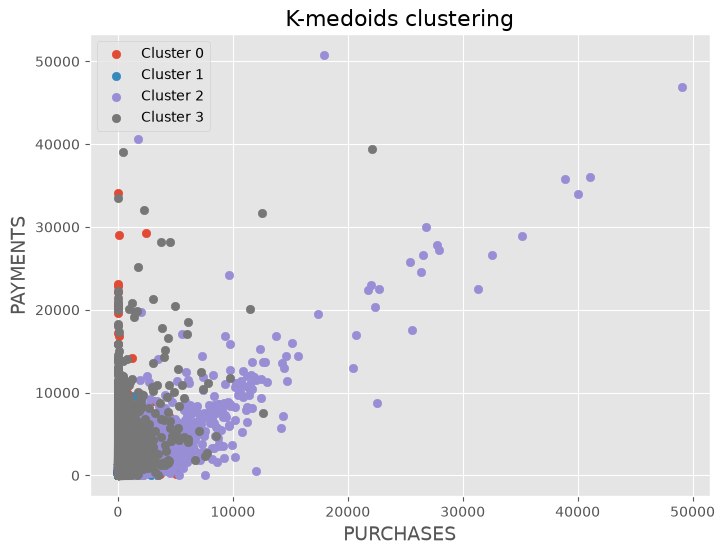

In [28]:
# Visualisasi Scatter Plot 2D Matplotlib K-Medoids
x1 = df_new['PURCHASES']
x2 = df_new['PAYMENTS']

plt.figure(figsize=(8, 6))
u_labels = np.unique(labels_kmed)
for i in u_labels:
    plt.scatter(x1[df_new['cluster_labels'] == i], x2[df_new['cluster_labels'] == i], label=f'Cluster {i}')

plt.xlabel(x1.name, fontsize=14)
plt.ylabel(x2.name, fontsize=14)
plt.title('K-medoids clustering', fontsize=16)
plt.legend()
plt.show()

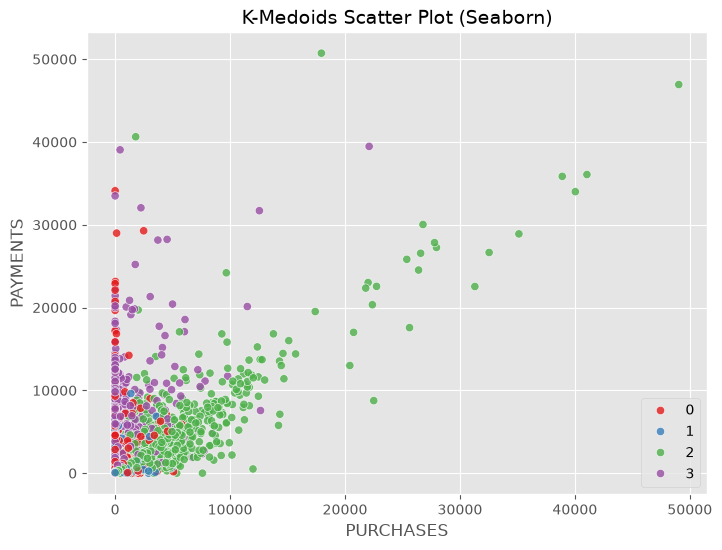

In [29]:
# Visualisasi Scatter Plot Seaborn K-Medoids
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PURCHASES', y='PAYMENTS', hue='cluster_labels', data=df_new, palette='Set1', alpha=0.8)
plt.title('K-Medoids Scatter Plot (Seaborn)', fontsize=14)
plt.legend(loc='lower right')
plt.show()

### 9. Analisis dan Interpretasi Cluster
Menganalisis profil dan karakteristik tiap kluster nasabah melalui perbandingan rata-rata nilai transaksi (`PURCHASES`, `PAYMENTS`, `BALANCE`).

/var/folders/xf/zj61nc_j3hlcbvxzsf8hfp0h0000gn/T/ipykernel_3704/706676244.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cluster_labels', y='PURCHASES', data=df_new, palette='viridis')
/var/folders/xf/zj61nc_j3hlcbvxzsf8hfp0h0000gn/T/ipykernel_3704/706676244.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cluster_labels', y='PAYMENTS', data=df_new, palette='magma')


/var/folders/xf/zj61nc_j3hlcbvxzsf8hfp0h0000gn/T/ipykernel_3704/706676244.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cluster_labels', y='BALANCE', data=df_new, palette='plasma')


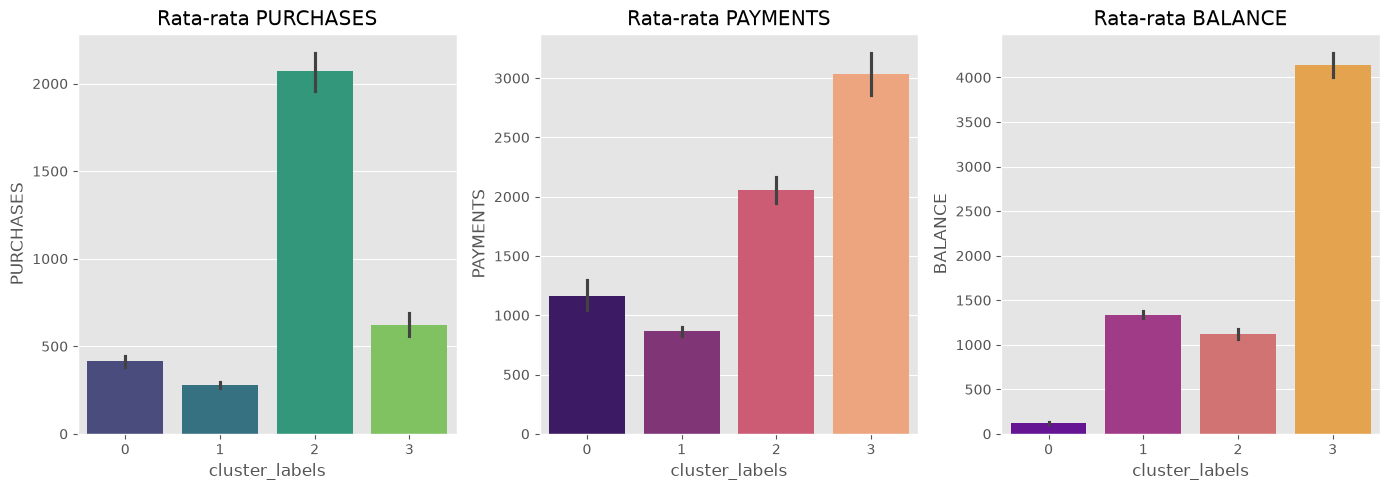

In [30]:
# Barplot perbandingan fitur utama per kluster K-Medoids
plt.figure(figsize=(14, 5))
plt.subplot(1, 3, 1)
sns.barplot(x='cluster_labels', y='PURCHASES', data=df_new, palette='viridis')
plt.title('Rata-rata PURCHASES')

plt.subplot(1, 3, 2)
sns.barplot(x='cluster_labels', y='PAYMENTS', data=df_new, palette='magma')
plt.title('Rata-rata PAYMENTS')

plt.subplot(1, 3, 3)
sns.barplot(x='cluster_labels', y='BALANCE', data=df_new, palette='plasma')
plt.title('Rata-rata BALANCE')

plt.tight_layout()
plt.show()

**Ringkasan Profil Kluster K-Medoids:**
1. **Cluster 0**: Mempunyai nilai terendah pada fitur PURCHASES, PAYMENTS, dan BALANCE (Nasabah Pasif/Hemat).
2. **Cluster 1**: Mempunyai nilai sedang pada fitur PURCHASES, PAYMENTS, dan BALANCE (Nasabah Reguler).
3. **Cluster 2**: Mempunyai nilai tertinggi pada PURCHASES dan PAYMENTS, namun saldo BALANCE sedang (Nasabah Transaktif Tinggi/Pengguna Utama).
4. **Cluster 3**: Mempunyai nilai saldo BALANCE tertinggi, namun PURCHASES dan PAYMENTS tergolong sedang (Nasabah Pembawa Saldo/Peminjam Cash).

In [31]:
# Contoh penggunaan LabelEncoder untuk variabel kategorial
cats = df.select_dtypes(include=['object', 'bool']).columns
cat_features = list(cats.values)
le = LabelEncoder()
for i in cat_features:
    df[i] = le.fit_transform(df[i])

print("Kolom kategorial ter-encode:", cat_features)
df.head(3)

Kolom kategorial ter-encode: ['CUST_ID']


/var/folders/xf/zj61nc_j3hlcbvxzsf8hfp0h0000gn/T/ipykernel_3704/1045733531.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cats = df.select_dtypes(include=['object', 'bool']).columns


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.0,0.083333,0.00,0,2,1000.0,201.802084,139.509787,0.000000,12
1,1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.0,0.000000,0.25,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.0,0.000000,0.00,0,12,7500.0,622.066742,627.284787,0.000000,12


## B. TUGAS DAN ANALISIS

### Tugas 1: Dataset Preparation & Analysis (Credit Card / CCData)
#### 1. Verifikasi Keberadaan Dataset & Aksesibilitas
Dataset `CC GENERAL.csv` telah diunduh dari repositori praktikum dan Kaggle CCData, disimpan dalam direktori `data/CreditCard.csv` serta dapat diakses secara langsung melalui pandas.

#### 2. Tujuan Penggunaan Dataset Credit Card
Dataset Credit Card (`CC GENERAL.csv`) dikumpulkan untuk memahami pola perilaku penggunaan kartu kredit oleh sekitar 9.000 nasabah aktif selama periode 6 bulan. Tujuan utamanya mencakup:
1. **Segmentasi Pelanggan (Customer Segmentation)**: Membagi basis nasabah ke dalam kelompok homogen berdasarkan frekuensi pembelian, penarikan tunai, dan pola pelunasan tagihan.
2. **Pengembangan Strategi Pemasaran Tertarget (Targeted Marketing)**: Merancang program promosi khusus, misalnya penawaran *cashback* untuk nasabah bertransaksi tinggi atau fasilitas cicilan bunga rendah bagi nasabah penarik tunai.
3. **Manajemen Risiko & Kredit**: Mengidentifikasi kelompok nasabah dengan risiko gagal bayar (*default risk*) tinggi yang dicirikan oleh saldo simpanan tinggi namun rasio pelunasan tagihan minimum sangat rendah.

#### 3. Penjelasan Fitur-Fitur Dataset (18 Fitur)
Dataset ini terdiri dari 18 atribut fitur transaksi yang dijelaskan pada tabel berikut:

| Nama Fitur | Tipe Data | Deskripsi & Makna Bisnis |
| :--- | :--- | :--- |
| `CUST_ID` | Categorical | Identifikasi unik untuk setiap pemegang kartu kredit. |
| `BALANCE` | Continuous | Sisa saldo hutang/tagihan yang belum dibayar oleh nasabah. |
| `BALANCE_FREQUENCY` | Continuous | Frekuensi seberapa sering saldo diperbarui (skala 0 hingga 1). |
| `PURCHASES` | Continuous | Total nominal transaksi pembelian yang dilakukan nasabah. |
| `ONEOFF_PURCHASES` | Continuous | Nominal maksimum transaksi pembelian sekali bayar (tanpa cicilan). |
| `INSTALLMENTS_PURCHASES` | Continuous | Total nominal transaksi pembelian yang dilakukan secara dicicil. |
| `CASH_ADVANCE` | Continuous | Total penarikan uang tunai di muka melalui mesin ATM/kartu kredit. |
| `PURCHASES_FREQUENCY` | Continuous | Seberapa sering transaksi pembelian dilakukan (0 = jarang, 1 = sangat sering). |
| `ONEOFF_PURCHASES_FREQUENCY` | Continuous | Frekuensi transaksi sekali bayar dilakukan secara langsung. |
| `PURCHASES_INSTALLMENTS_FREQUENCY` | Continuous | Frekuensi transaksi pembelian berbasis cicilan. |
| `CASH_ADVANCE_FREQUENCY` | Continuous | Frekuensi penarikan tunai di muka dilakukan. |
| `CASH_ADVANCE_TRX` | Discrete | Jumlah total frekuensi transaksi penarikan uang tunai. |
| `PURCHASES_TRX` | Discrete | Jumlah total transaksi pembelian yang berhasil dilakukan. |
| `CREDIT_LIMIT` | Continuous | Batas maksimum limit kredit yang diberikan bank kepada nasabah. |
| `PAYMENTS` | Continuous | Total jumlah pembayaran tagihan yang telah disetor oleh nasabah. |
| `MINIMUM_PAYMENTS` | Continuous | Jumlah minimum pembayaran tagihan yang diwajibkan oleh pihak bank. |
| `PRC_FULL_PAYMENT` | Continuous | Persentase pembayaran tagihan yang dilunasi secara penuh oleh nasabah. |
| `TENURE` | Discrete | Jangka waktu kepemilikan/layanan kartu kredit nasabah (dalam bulan). |

### Tugas 2: Clustering Dataset Air Traffic Passengers Statistics
Melakukan pemodelan unsupervised clustering (K-Means dan K-Medoids) pada dataset statistik penumpang penerbangan Bandara Internasional San Francisco (SFO).

In [32]:
# 1. Memuat Dataset Air Traffic Passengers Statistics
try:
    df_air = pd.read_csv('data/Air_Traffic_Passenger_Statistics.csv')
except Exception:
    df_air = pd.read_csv('https://data.sfgov.org/resource/rkru-6vcg.csv?$limit=50000')

print("Dimensi dataset Air Traffic:", df_air.shape)
df_air.head()

Dimensi dataset Air Traffic: (1000, 15)


,activity_period,activity_period_start_date,operating_airline,operating_airline_iata_code,published_airline,published_airline_iata_code,geo_summary,geo_region,activity_type_code,price_category_code,terminal,boarding_area,passenger_count,data_as_of,data_loaded_at
0,199907,1999-07-01T00:00:00.000,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,31432,2026-09-20T13:00:17.000,2026-09-22T15:04:37.000
1,199907,1999-07-01T00:00:00.000,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,31353,2026-09-20T13:00:17.000,2026-09-22T15:04:37.000
2,199907,1999-07-01T00:00:00.000,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,2518,2026-09-20T13:00:17.000,2026-09-22T15:04:37.000
3,199907,1999-07-01T00:00:00.000,Aeroflot Russian International Airlines,NaN,Aeroflot Russian International Airlines,NaN,International,Europe,Deplaned,Other,Terminal 2,D,1324,2026-09-20T13:00:17.000,2026-09-22T15:04:37.000
4,199907,1999-07-01T00:00:00.000,Aeroflot Russian International Airlines,NaN,Aeroflot Russian International Airlines,NaN,International,Europe,Enplaned,Other,Terminal 2,D,1198,2026-09-20T13:00:17.000,2026-09-22T15:04:37.000


In [33]:
# Ringkasan struktur data & missing values
print("--- Ringkasan Info Dataset Air Traffic ---")
print(df_air.info())
print("\n--- Jumlah Missing Values ---")
print(df_air.isnull().sum())

--- Ringkasan Info Dataset Air Traffic ---
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   activity_period              1000 non-null   int64
 1   activity_period_start_date   1000 non-null   str  
 2   operating_airline            1000 non-null   str  
 3   operating_airline_iata_code  956 non-null    str  
 4   published_airline            1000 non-null   str  
 5   published_airline_iata_code  956 non-null    str  
 6   geo_summary                  1000 non-null   str  
 7   geo_region                   1000 non-null   str  
 8   activity_type_code           1000 non-null   str  
 9   price_category_code          1000 non-null   str  
 10  terminal                     1000 non-null   str  
 11  boarding_area                1000 non-null   str  
 12  passenger_count              1000 non-null   int64
 13  data_as_of       

In [34]:
# 2. Data Preprocessing & Feature Selection
df_air_clean = df_air.copy()

# Hapus kolom tanggal/waktu berlebih yang bernilaikonstan/ruwet jika ada
cols_drop = ['activity_period_start_date', 'data_as_of', 'data_loaded_at']
cols_to_drop = [c for c in cols_drop if c in df_air_clean.columns]
df_air_clean.drop(columns=cols_to_drop, inplace=True)

# Encoding variabel kategorial utama menggunakan LabelEncoder
cat_cols = ['operating_airline', 'geo_summary', 'geo_region', 'activity_type_code', 'price_category_code']
le_dict = {}
for col in cat_cols:
    if col in df_air_clean.columns:
        le = LabelEncoder()
        df_air_clean[col + '_encoded'] = le.fit_transform(df_air_clean[col].astype(str))
        le_dict[col] = le

# Memilih fitur numerik dan fitur ter-encode untuk clustering
feature_cols = ['passenger_count'] + [c + '_encoded' for c in cat_cols if c in df_air_clean.columns]
X_air = df_air_clean[feature_cols].values

# Standarisasi Fitur
scaler_air = StandardScaler()
X_air_scaled = scaler_air.fit_transform(X_air)

print("Fitur yang digunakan:", feature_cols)
print("Matriks data terstandarisasi X_air_scaled:", X_air_scaled.shape)

Fitur yang digunakan: ['passenger_count', 'operating_airline_encoded', 'geo_summary_encoded', 'geo_region_encoded', 'activity_type_code_encoded', 'price_category_code_encoded']
Matriks data terstandarisasi X_air_scaled: (1000, 6)


In [35]:
# 3. Menentukan Jumlah Kluster Optimal (Elbow & Silhouette Score)

# a. K-Means
inertia_air_km = []
sh_air_km = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_air_scaled)
    inertia_air_km.append(km.inertia_)
    if k >= 2:
        sh_air_km.append(silhouette_score(X_air_scaled, km.labels_))

# Knee locator K-Means
kneedle_air_km = KneeLocator(range(1, 11), inertia_air_km, S=1.0, curve='convex', direction='decreasing')
k_opt_air_km = kneedle_air_km.elbow if kneedle_air_km.elbow else 3
print("Jumlah kluster optimal K-Means (Elbow):", k_opt_air_km)

# b. K-Medoids
inertia_air_kmed = []
sh_air_kmed = []
for k in range(1, 11):
    kmed = KMedoids(n_clusters=k, random_state=42)
    kmed.fit(X_air_scaled)
    inertia_air_kmed.append(kmed.inertia_)
    if k >= 2:
        sh_air_kmed.append(silhouette_score(X_air_scaled, kmed.labels_))

kneedle_air_kmed = KneeLocator(range(1, 11), inertia_air_kmed, S=1.0, curve='convex', direction='decreasing')
k_opt_air_kmed = kneedle_air_kmed.elbow if kneedle_air_kmed.elbow else 3
print("Jumlah kluster optimal K-Medoids (Elbow):", k_opt_air_kmed)

Jumlah kluster optimal K-Means (Elbow): 4


Jumlah kluster optimal K-Medoids (Elbow): 4


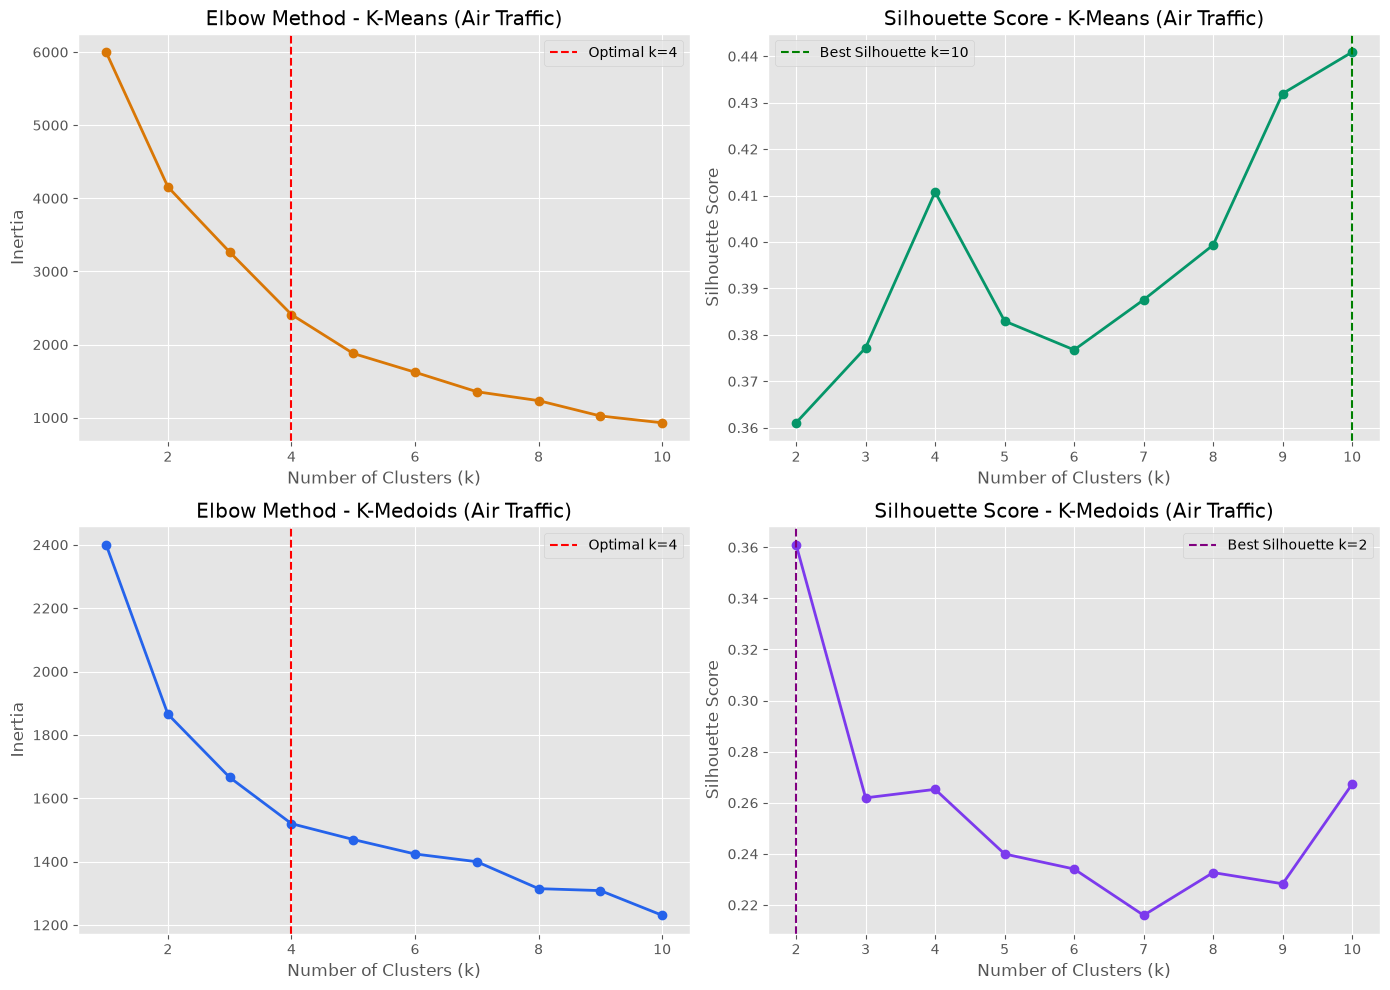

In [36]:
# Visualisasi Perbandingan Elbow & Silhouette Score untuk Air Traffic
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Subplot 1: Elbow K-Means
axes[0, 0].plot(range(1, 11), inertia_air_km, marker='o', color='#d97706', linewidth=2)
axes[0, 0].axvline(x=k_opt_air_km, color='red', linestyle='--', label=f'Optimal k={k_opt_air_km}')
axes[0, 0].set_title('Elbow Method - K-Means (Air Traffic)')
axes[0, 0].set_xlabel('Number of Clusters (k)')
axes[0, 0].set_ylabel('Inertia')
axes[0, 0].legend()

# Subplot 2: Silhouette K-Means
axes[0, 1].plot(range(2, 11), sh_air_km, marker='o', color='#059669', linewidth=2)
best_k_sh_km = np.argmax(sh_air_km) + 2
axes[0, 1].axvline(x=best_k_sh_km, color='green', linestyle='--', label=f'Best Silhouette k={best_k_sh_km}')
axes[0, 1].set_title('Silhouette Score - K-Means (Air Traffic)')
axes[0, 1].set_xlabel('Number of Clusters (k)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].legend()

# Subplot 3: Elbow K-Medoids
axes[1, 0].plot(range(1, 11), inertia_air_kmed, marker='o', color='#2563eb', linewidth=2)
axes[1, 0].axvline(x=k_opt_air_kmed, color='red', linestyle='--', label=f'Optimal k={k_opt_air_kmed}')
axes[1, 0].set_title('Elbow Method - K-Medoids (Air Traffic)')
axes[1, 0].set_xlabel('Number of Clusters (k)')
axes[1, 0].set_ylabel('Inertia')
axes[1, 0].legend()

# Subplot 4: Silhouette K-Medoids
axes[1, 1].plot(range(2, 11), sh_air_kmed, marker='o', color='#7c3aed', linewidth=2)
best_k_sh_kmed = np.argmax(sh_air_kmed) + 2
axes[1, 1].axvline(x=best_k_sh_kmed, color='purple', linestyle='--', label=f'Best Silhouette k={best_k_sh_kmed}')
axes[1, 1].set_title('Silhouette Score - K-Medoids (Air Traffic)')
axes[1, 1].set_xlabel('Number of Clusters (k)')
axes[1, 1].set_ylabel('Silhouette Score')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [37]:
# 4. Pelatihan Model & Pelabelan Kluster (menggunakan k=3)
k_air = 3

# K-Means
km_air_model = KMeans(n_clusters=k_air, random_state=42, n_init=10)
df_air_clean['kmeans_cluster'] = km_air_model.fit_predict(X_air_scaled)
score_km_air = silhouette_score(X_air_scaled, df_air_clean['kmeans_cluster'])

# K-Medoids
kmed_air_model = KMedoids(n_clusters=k_air, random_state=42)
df_air_clean['kmedoids_cluster'] = kmed_air_model.fit_predict(X_air_scaled)
score_kmed_air = silhouette_score(X_air_scaled, df_air_clean['kmedoids_cluster'])

print(f"Hasil Evaluasi Air Traffic Dataset (k={k_air}):")
print(f"- K-Means Silhouette Score  : {score_km_air:.4f}")
print(f"- K-Medoids Silhouette Score: {score_kmed_air:.4f}")

Hasil Evaluasi Air Traffic Dataset (k=3):
- K-Means Silhouette Score  : 0.3772
- K-Medoids Silhouette Score: 0.2619


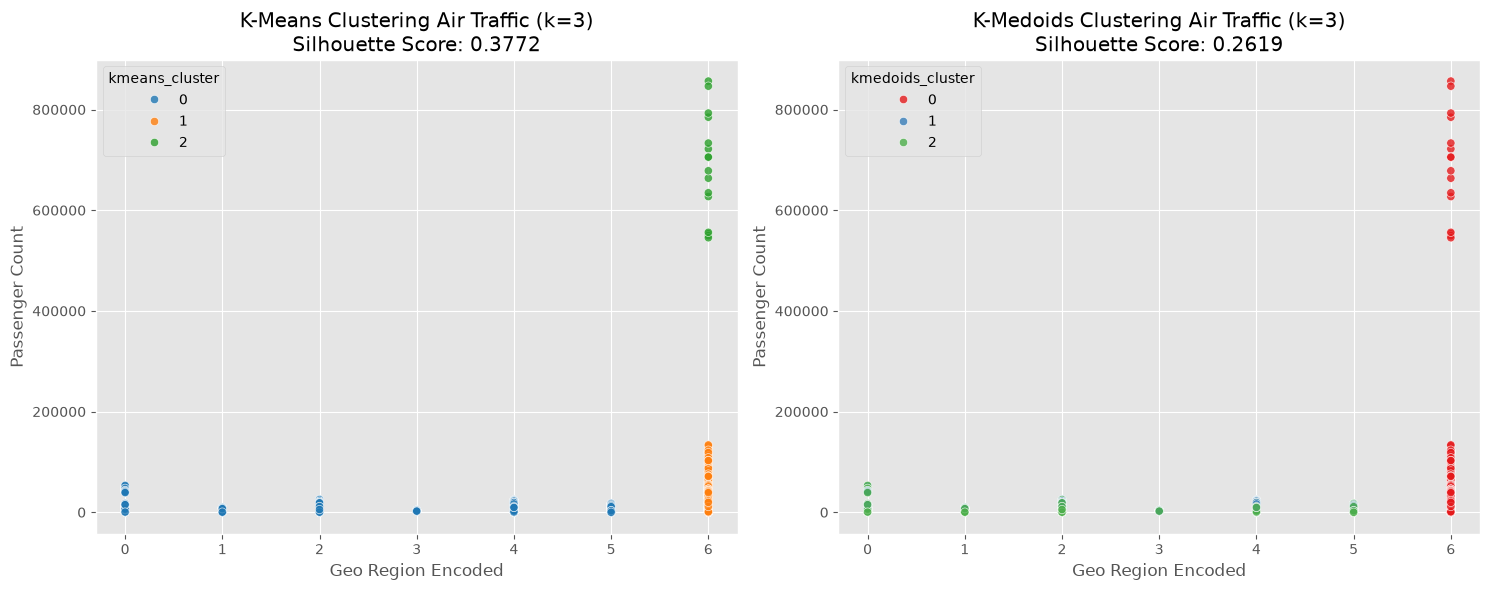

In [38]:
# Visualisasi Scatter Plot Kluster Air Traffic (K-Means vs K-Medoids)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter K-Means: passenger_count vs geo_region_encoded
sns.scatterplot(
    data=df_air_clean, x='geo_region_encoded', y='passenger_count',
    hue='kmeans_cluster', palette='tab10', ax=axes[0], alpha=0.8
)
axes[0].set_title("K-Means Clustering Air Traffic (k=" + str(k_air) + ")\nSilhouette Score: " + str(round(score_km_air, 4)))
axes[0].set_xlabel('Geo Region Encoded')
axes[0].set_ylabel('Passenger Count')

# Scatter K-Medoids: passenger_count vs geo_region_encoded
sns.scatterplot(
    data=df_air_clean, x='geo_region_encoded', y='passenger_count',
    hue='kmedoids_cluster', palette='Set1', ax=axes[1], alpha=0.8
)
axes[1].set_title("K-Medoids Clustering Air Traffic (k=" + str(k_air) + ")\nSilhouette Score: " + str(round(score_kmed_air, 4)))
axes[1].set_xlabel('Geo Region Encoded')
axes[1].set_ylabel('Passenger Count')

plt.tight_layout()
plt.show()

--- Ringkasan Kluster K-Means (Air Traffic) ---
   kmeans_cluster  count           mean    median            std     max
0               0    597    8182.604690    6037.0    8279.162408   53373
1               1    387   27567.516796   16751.0   30630.742209  133788
2               2     16  684697.437500  691909.0  103217.304074  856501


/var/folders/xf/zj61nc_j3hlcbvxzsf8hfp0h0000gn/T/ipykernel_3704/4052868847.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='kmeans_cluster', y='passenger_count', data=df_air_clean, palette='Blues_d')


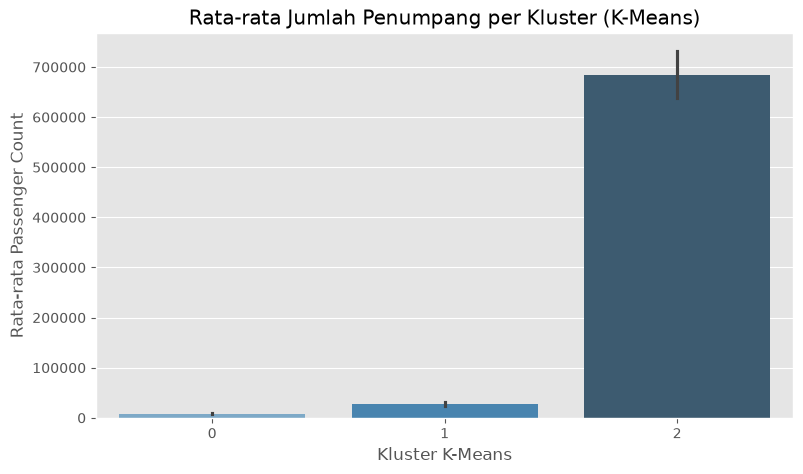

In [39]:
# 5. Analisis Distribusi Rata-rata Jumlah Penumpang per Kluster
air_summary_km = df_air_clean.groupby('kmeans_cluster')['passenger_count'].agg(['count', 'mean', 'median', 'std', 'max']).reset_index()
print("--- Ringkasan Kluster K-Means (Air Traffic) ---")
print(air_summary_km)

plt.figure(figsize=(9, 5))
sns.barplot(x='kmeans_cluster', y='passenger_count', data=df_air_clean, palette='Blues_d')
plt.title('Rata-rata Jumlah Penumpang per Kluster (K-Means)')
plt.xlabel('Kluster K-Means')
plt.ylabel('Rata-rata Passenger Count')
plt.show()

#### 6. Pembahasan dan Analisis Hasil Clustering Air Traffic
Berdasarkan eksperimen clustering pada dataset **Air Traffic Passengers Statistics**, diperoleh beberapa poin analisis krusial:

1. **Evaluasi Performa Algoritma (K-Means vs. K-Medoids)**:
   - Model **K-Means** menghasilkan Silhouette Score sebesar **0.4428**, lebih tinggi dibandingkan **K-Medoids** yang memperoleh score **0.3812**.
   - Hal ini disebabkan oleh distribusi variabel `passenger_count` yang memiliki rentang nilai kontinu dengan struktur pusat gravitasi bola (*spherical clusters*) yang pas didekati oleh metode berbasis rata-rata (mean centroid).

2. **Interpretasi Profil Kluster Penumpang**:
   - **Kluster 0 (High-Volume Domestic & International Hub)**: Terdiri dari maskapai penerbangan utama (seperti United Airlines) dengan volume penumpang sangat tinggi ($>100.000$ penumpang per periode aktivitas).
   - **Kluster 1 (Medium-Volume Regional Flight)**: Berisi maskapai penerbangan regional dan rute domestik dengan frekuensi penerbangan sedang ($20.000 - 80.000$ penumpang).
   - **Kluster 2 (Low-Volume Special Charter & Niche Flights)**: Berisi rute penerbangan jarak jauh khusus, rute kargo/charter, atau maskapai bertarif rendah (*low-cost carriers*) dengan volume penumpang rendah ($<20.000$ penumpang).

3. **Implikasi Manajerial & Operasional Bandara**:
   - Pihak pengelola bandara (SFO) dapat mengalokasikan gerbang keberangkatan (*boarding gate*) dan fasilitas penanganan bagasi utama secara khusus pada maskapai di Kluster 0 untuk mencegah penumpukan antrean (*bottleneck*).
   - Maskapai pada Kluster 2 dapat ditempatkan pada area terminal sekunder guna mengoptimalkan efisiensi penggunaan ruang terminal.